In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
# matplotlib.use('TkAgg')

import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime

import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/baostock')
import datasource

In [2]:
# 这个是筛选多少天上涨多少的，
codes = datasource.get_codes()
code = codes[0]
dt = datasource.get_data(code)
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST
date,,,,,,,,,,,,,
2010-01-04,sh.600000,5.079055,5.088362,4.923170,4.930150,5.046482,66191338,1.419984e+09,2,0.835129,1,-2.3052,0
2010-01-05,sh.600000,4.981336,5.020889,4.837085,4.967376,4.930150,115147943,2.436891e+09,2,1.452808,1,0.7551,0
2010-01-06,sh.600000,4.953417,4.955743,4.858024,4.869658,4.967376,96782575,2.034174e+09,2,1.221095,1,-1.9672,0
2010-01-07,sh.600000,4.858024,4.895251,4.723079,4.760305,4.869658,85236072,1.761801e+09,2,1.075414,1,-2.2456,0
2010-01-08,sh.600000,4.732386,4.839411,4.723079,4.813818,4.760305,65707646,1.349532e+09,2,0.829026,1,1.1241,0


In [3]:
# 这里是取得左右的
dt['rsi'] = talib.RSI(dt['close'], timeperiod=14)
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,rsi
date,,,,,,,,,,,,,,
2010-01-04,sh.600000,5.079055,5.088362,4.923170,4.930150,5.046482,66191338,1.419984e+09,2,0.835129,1,-2.3052,0,NaN
2010-01-05,sh.600000,4.981336,5.020889,4.837085,4.967376,4.930150,115147943,2.436891e+09,2,1.452808,1,0.7551,0,NaN
2010-01-06,sh.600000,4.953417,4.955743,4.858024,4.869658,4.967376,96782575,2.034174e+09,2,1.221095,1,-1.9672,0,NaN
2010-01-07,sh.600000,4.858024,4.895251,4.723079,4.760305,4.869658,85236072,1.761801e+09,2,1.075414,1,-2.2456,0,NaN
2010-01-08,sh.600000,4.732386,4.839411,4.723079,4.813818,4.760305,65707646,1.349532e+09,2,0.829026,1,1.1241,0,NaN


我打算横轴是rsi，纵轴是涨跌幅

In [4]:
dt['radio'] = (dt['close']-dt['preclose'])/dt['preclose']*100
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,rsi,radio
date,,,,,,,,,,,,,,,
2010-01-04,sh.600000,5.079055,5.088362,4.923170,4.930150,5.046482,66191338,1.419984e+09,2,0.835129,1,-2.3052,0,NaN,-2.305210
2010-01-05,sh.600000,4.981336,5.020889,4.837085,4.967376,4.930150,115147943,2.436891e+09,2,1.452808,1,0.7551,0,NaN,0.755073
2010-01-06,sh.600000,4.953417,4.955743,4.858024,4.869658,4.967376,96782575,2.034174e+09,2,1.221095,1,-1.9672,0,NaN,-1.967213
2010-01-07,sh.600000,4.858024,4.895251,4.723079,4.760305,4.869658,85236072,1.761801e+09,2,1.075414,1,-2.2456,0,NaN,-2.245581
2010-01-08,sh.600000,4.732386,4.839411,4.723079,4.813818,4.760305,65707646,1.349532e+09,2,0.829026,1,1.1241,0,NaN,1.124145


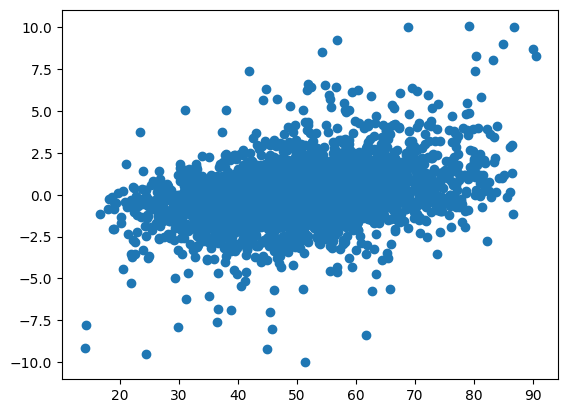

In [5]:
plt.scatter(dt['rsi'], dt['radio'])
plt.show()

In [6]:
# 我期望将rsi和kdj都放在某个范围
dt = dt.dropna()
dt['rsi'] = dt['rsi'].astype(int)
dt['radio'] = (dt['radio']*10).astype(int)
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,rsi,radio
date,,,,,,,,,,,,,,,
2010-01-22,sh.600000,4.699813,4.909210,4.655607,4.862678,4.762632,154445976,3.188524e+09,2,1.948627,1,2.1006,0,46,21
2010-01-25,sh.600000,4.783572,4.881291,4.750999,4.760305,4.862678,80232725,1.658597e+09,2,1.012287,1,-2.1053,0,42,-21
2010-01-26,sh.600000,4.767285,4.862678,4.692833,4.813818,4.760305,91936559,1.885519e+09,2,1.159953,1,1.1241,0,45,11
2010-01-27,sh.600000,4.809165,4.839411,4.602094,4.620707,4.813818,94264363,1.898605e+09,2,1.189323,1,-4.0116,0,37,-40
2010-01-28,sh.600000,4.602094,4.618380,4.509028,4.583481,4.620707,58691704,1.152620e+09,2,0.740506,1,-0.8056,0,36,-8


In [7]:
dt2 = dt.groupby(['rsi', 'radio']).size()

In [8]:
dt3 = dt2.reset_index()
dt3.head()

,rsi,radio,0
0,13,-91,1
1,14,-77,1
2,16,-11,1
3,17,-8,1
4,18,-20,1


In [9]:
# 这里要画图，请注意，最后一列是数量
dt3.rename(columns={0:'count'})

,rsi,radio,count
0,13,-91,1
1,14,-77,1
2,16,-11,1
3,17,-8,1
4,18,-20,1
...,...,...,...
1796,86,28,1
1797,86,29,1
1798,86,100,1
1799,90,82,1


In [10]:
# 这里要缩小范围，radio 的范围是-100到100
dt4 = dt3.loc[(dt3['radio']<=100) & (dt3['radio']>=-100)]
dt4 = dt4.rename(columns={0:'count'})
dt4.head()

,rsi,radio,count
0,13,-91,1
1,14,-77,1
2,16,-11,1
3,17,-8,1
4,18,-20,1


In [11]:
img = np.zeros((100,201))
for index, row in dt4.iterrows():
    _row_index = row['rsi']
    _column_index = row['radio']+100
    _count = row['count']
    img[_row_index,_column_index] = _count

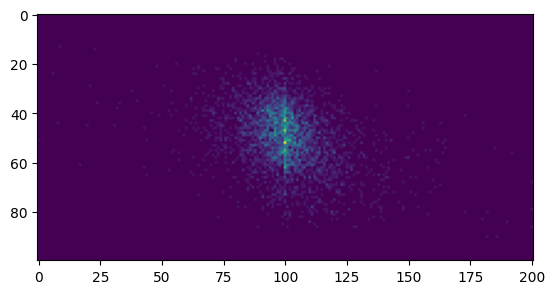

In [12]:
plt.imshow(img)

In [13]:
img2 = np.zeros((100,201))

In [14]:
img2.shape

(100, 201)

# 遍历所有的股票

In [15]:
lst_dt_rsi = []
lst_dt_kdj = []

for i in tqdm(range(len(codes))):
    code = codes[i]
    dt = datasource.get_data(code)
    # 指标
    if len(dt) < 30:
        continue
    dt['rsi'] = talib.RSI(dt['close'], timeperiod=14)
    dt['K'], dt['D'] = talib.STOCH(dt['high'].values, dt['low'].values, dt['close'].values, fastk_period=9, slowk_period=3,
                               slowk_matype=0, slowd_period=3, slowd_matype=0)
    dt['K'] = dt['K'].fillna(0)
    dt['D'] = dt['D'].fillna(0)
    dt['J']=3*dt['K']-2*dt['D']
    dt['radio'] = (dt['close']-dt['preclose'])/dt['preclose']*100
    dt = dt.dropna()
    # 取得整数
    dt['rsi'] = dt['rsi'].astype(int)
    dt['kdj'] = dt['J'].astype(int)
    dt['radio'] = (dt['radio']*10).astype(int)
    # 计数
    dt2 = dt.groupby(['rsi', 'radio']).size()
    # 重置索引
    dt3 = dt2.reset_index()
    # 缩小范围
    dt4 = dt3.loc[(dt3['radio']<=100) & (dt3['radio']>=-100)]
    dt4 = dt4.rename(columns={0:'count'})
    #
    lst_dt_rsi.append(dt4)
    #
    dt5 = dt.groupby(['kdj', 'radio']).size().reset_index()
    dt6 = dt5.loc[(dt5['radio']<=100) & (dt5['radio']>=-100)]
    dt7 = dt6.rename(columns={0:'count'})
    lst_dt_kdj.append(dt7)
    
    

100%|██████████████████████████████████████████████████████████████████████████████| 5493/5493 [04:24<00:00, 20.75it/s]


In [16]:
def show_img(dts, rsi):
    dt_all = pd.concat(dts,  ignore_index=True)
    dt_all_group = dt_all.groupby([rsi, 'radio']).sum()
    dt_all_group_2 = dt_all_group.reset_index()
    dt_all_group_2['count'] = (dt_all_group_2['count']-dt_all_group_2['count'].min()) /(dt_all_group_2['count'].max()-dt_all_group_2['count'].min())*255
    dt_all_group_2['count'] = dt_all_group_2['count'].astype(int)
    img = np.zeros((101,201))
    for index, row in dt_all_group_2.iterrows():
        _row_index = row[rsi]
        _column_index = row['radio']+100
        _count = row['count']
        # 这里取消范围外的
        if _row_index < 0 or _row_index >= img.shape[0] or _column_index < 0 or _column_index >= 2 * img.shape[0]:
            continue
        img[_row_index,_column_index] = _count
    plt.imshow(img)

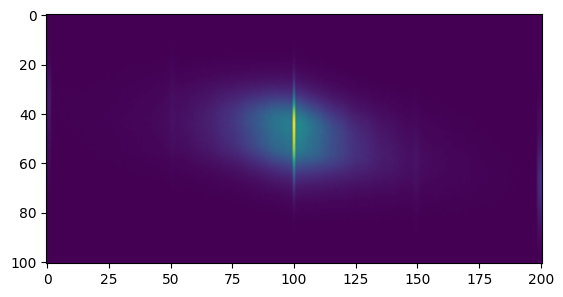

In [17]:
show_img(lst_dt_rsi, 'rsi')

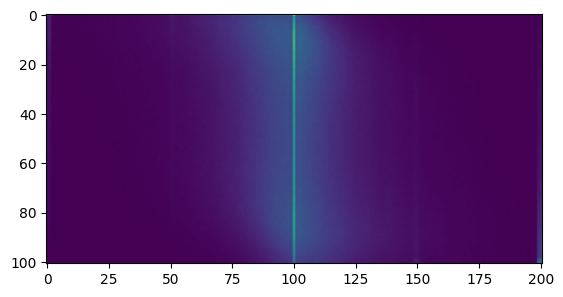

In [18]:
show_img(lst_dt_kdj, 'kdj')

In [19]:
def show_img_gray(dts, rsi, threshold=1):
    # 这个会二值化图形
    dt_all = pd.concat(dts,  ignore_index=True)
    dt_all_group = dt_all.groupby([rsi, 'radio']).sum()
    dt_all_group_2 = dt_all_group.reset_index()
    dt_all_group_2['count'] = (dt_all_group_2['count']-dt_all_group_2['count'].min()) /(dt_all_group_2['count'].max()-dt_all_group_2['count'].min())*255
    dt_all_group_2['count'] = dt_all_group_2['count'].astype(int)
    img = np.zeros((101,201))
    for index, row in dt_all_group_2.iterrows():
        _row_index = row[rsi]
        _column_index = row['radio']+100
        _count = row['count']
        # 这里取消范围外的
        if _row_index < 0 or _row_index >= img.shape[0] or _column_index < 0 or _column_index >= 2 * img.shape[0]:
            continue
        img[_row_index,_column_index] = _count
    threshold = 1
    img2 = np.where(img > threshold, 255, 0)
    plt.imshow(img2)

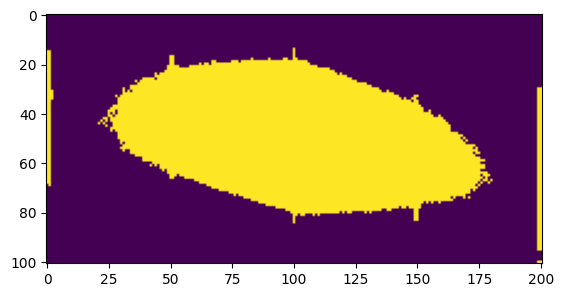

In [20]:
show_img_gray(lst_dt_rsi, 'rsi')

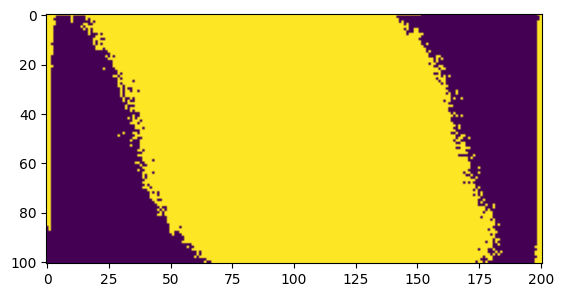

In [21]:
show_img_gray(lst_dt_kdj, 'kdj')

NameError: name 'b' is not defined